# 第12章：横截面排序与股票组合

**问题：同一个调仓日，小市值股票与大市值股票的后续表现有什么不同？**

本章使用第11章共享 `data/stock_daily.parquet` 的全部可用历史。
主线：市值排序 → 分组 → 权重 → 持有收益 → 净值比较。

教学假设：每个调仓日都能按当日估值完成买卖，全部资金投入股票；含红利可比价格统一 `ffill()`，之后直接用于计算，不考虑停牌、涨跌停及成交限制。结果是该假设下的组合研究。

第1–10节完成主要分析；最后第11节为换手与成本选学，可跳过。

## 1. 环境、路径与参数

使用课程根目录 `.venv`，无需重新安装依赖。Windows与macOS使用相同Notebook代码。
从课程根目录、本章目录或Notebook目录启动均可。只读共享行情，不复制或重建Parquet。

`Dsmvtl2`是总股数乘A股价格的“总市值2”（千元），不是A/B/H分别按各自价格加总的市值。
信号日保留正常交易状态、有效市值及有效历史估值的A股；不按未来收益或未来存续情况筛选。

In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "Chapter11 - 股票日频收益率分析/data/stock_daily.parquet").is_file())
CHAPTER = ROOT / "Chapter12 - 横截面排序与股票组合"
SOURCE = ROOT / "Chapter11 - 股票日频收益率分析/data/stock_daily.parquet"
TABLES = CHAPTER / "outputs/tables"
FIGURES = CHAPTER / "latex/figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SIZE = "Dsmvtl2"
N_GROUPS = 5
GROUPS = [f"G{i}" for i in range(1, N_GROUPS + 1)]
BOARD = {1: "沪主板", 4: "深主板", 16: "创业板", 32: "科创板", 64: "北交所"}
fonts = {f.name for f in font_manager.fontManager.ttflist}
font = next((f for f in ["Microsoft YaHei", "PingFang SC", "SimHei"] if f in fonts), "DejaVu Sans")
plt.rcParams.update({"font.family": font, "axes.unicode_minus": False,
                     "figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False})
pd.set_option("display.max_columns", 12)
print("共享输入：", SOURCE.relative_to(ROOT))
print("Python / pandas：", platform.python_version(), pd.__version__)

共享输入： Chapter11 - 股票日频收益率分析\data\stock_daily.parquet
Python / pandas： 3.11.15 2.3.3


## 2. 读取最长历史与核对数据

只选本章使用的列，但不按年份截断。行情日期是交易所本地日期。
先检查代码×日期唯一性；重复键应调查来源，不能用随手去重掩盖问题。
真实交易日期从A股非填充、有成交记录中取得，节假日填充不能进入交易日历。

In [2]:
columns = ["Stkcd", "Trddt", "Markettype", "Trdsta", "Filling", "Dnshrtrd",
           "Dsmvtl2", "Dsmvosd", "Adjprcwd"]
raw = pd.read_parquet(SOURCE, columns=columns)
raw["Stkcd"] = raw["Stkcd"].astype("string").str.zfill(6)
source_rows = pq.ParquetFile(SOURCE).metadata.num_rows
assert len(raw) == source_rows
assert raw[["Stkcd", "Trddt"]].notna().all().all()
assert not raw.duplicated(["Stkcd", "Trddt"]).any()
data = raw.loc[raw.Markettype.isin(BOARD)].copy()
source_start, source_end = raw.Trddt.min(), raw.Trddt.max()
calendar = pd.DatetimeIndex(sorted(data.loc[data.Filling.eq(0) & data.Dnshrtrd.gt(0), "Trddt"].unique()))
profile = data.groupby(data.Trddt.dt.year).agg(
    rows=("Stkcd", "size"), stocks=("Stkcd", "nunique"), recorded_dates=("Trddt", "nunique"))
profile["trading_dates"] = pd.Series(calendar.year).value_counts().sort_index()
print(f"全包{len(raw):,}行；A股{len(data):,}行；{source_start.date()}至{source_end.date()}")
display(profile)
display(data[[SIZE, "Adjprcwd"]].isna().sum().rename("缺失记录数").to_frame())
del raw

全包6,888,585行；A股6,778,694行；2021-08-16至2026-08-13


,rows,stocks,recorded_dates,trading_dates
Trddt,,,,
2021,458867,4688,100,93
2022,1260986,5113,260,242
2023,1354201,5380,260,242
2024,1403825,5435,262,242
2025,1414730,5500,261,243
2026,886085,5564,161,148


,缺失记录数
Dsmvtl2,0
Adjprcwd,389


### 2.1 统一价格矩阵

使用含红利可比价格 `Adjprcwd`，价格比值包含现金红利再投资。
先把长表转成“日期×股票”矩阵，按市场交易日对齐，再用 `ffill()` 沿用过去最后有效价格。填充后的价格直接用于建仓、持有及调仓计算。

`ffill()`无法填补第一笔有效价格之前的缺失，所以入选股票必须在信号日已经有正的有效估值。不向前使用未来价格。

In [3]:
actual = data.loc[data.Filling.eq(0)].copy()
# 非正或无穷价格不作为有效估值；之后沿日期使用过去最后有效值。
actual["Adjprcwd"] = actual.Adjprcwd.where(np.isfinite(actual.Adjprcwd) & actual.Adjprcwd.gt(0))
# 行是日期、列是股票；统一市场交易日后向前填充，后续只使用这张价格表。
prices = actual.pivot(index="Trddt", columns="Stkcd", values="Adjprcwd").reindex(calendar).ffill()
display(prices.iloc[:5, :5])

Stkcd,000001,000002,000004,000005,000006
2021-08-16,3015.635523,2779.942892,83.322209,21.162805,322.895459
2021-08-17,2973.311078,2799.316314,84.341239,21.367280,316.672617
2021-08-18,3116.913083,2871.964171,83.322228,21.265038,319.438436
2021-08-19,3074.588521,2802.950872,82.616739,20.958332,315.289889
2021-08-20,2935.521807,2754.518684,77.443362,20.958332,315.981320


## 3. 先画时间线，再写回测

设月末最后交易日为 $e$，其前一交易日为 $s$：

1. $s$收盘后：按当日市值与可见状态筛选、排序。
2. $e$收盘：按预定分组建仓；当天收益不归新组合。
3. $e$之后至下个月末：持有并估值，月内权重自然漂移。

为了不把2026年8月13日误认为8月月末，最后一个数据月份不生成新调仓；已有组合继续估值至文件末日。
第一期不需要收益回看窗口，所以2021年8月底即可建仓。

In [4]:
# 将市场交易日按自然月分组，避免把周末、节假日当作调仓日。
month_dates = pd.Series(calendar, index=calendar).groupby(calendar.to_period("M"))
schedule_rows = []
for month, dates in month_dates:
    if month == calendar[-1].to_period("M"):
        continue  # 数据结束月份没有后续月份来确认完整月末
    # 倒数第二日收盘形成信号，最后一日收盘建仓；新组合不赚取建仓日当天的收益。
    signal, execution = dates.iloc[-2], dates.iloc[-1]
    schedule_rows.append({"signal_date": signal, "execution_date": execution})
schedule = pd.DataFrame(schedule_rows)
# shift(-1)把下一次建仓日对齐到本期，作为本期持有终点。
# 这里使用未来日期来划分收益区间，不使用未来市值或收益决定选股；末期持有至数据末日。
schedule["holding_end"] = schedule.execution_date.shift(-1).fillna(calendar[-1])
assert (schedule.signal_date < schedule.execution_date).all()
assert (schedule.execution_date < schedule.holding_end).all()
display(pd.concat([schedule.head(3), schedule.tail(3)]))

,signal_date,execution_date,holding_end
0,2021-08-30,2021-08-31,2021-09-30
1,2021-09-29,2021-09-30,2021-10-29
2,2021-10-28,2021-10-29,2021-11-30
57,2026-05-28,2026-05-29,2026-06-30
58,2026-06-29,2026-06-30,2026-07-31
59,2026-07-30,2026-07-31,2026-08-13


### 3.1 只依据当时信息选股

在每个信号日，保留正常交易状态（`Trdsta == 1`）、正且有限市值、已有有效历史估值的A股。成交量不作为个股入选条件。

先按市值、代码排序，再用顺序位置均分五组。G1最小，G5最大；同市值的边界股票按代码分开。不要求股票在样本结束时仍存在。

In [5]:
# 只取各信号日的股票截面，后续筛选不查看股票未来是否存续或是否有收益记录。
signal_rows = data.loc[data.Trddt.isin(schedule.signal_date)].copy()
# 把信号日填充后的价格按“日期、股票”匹配回来；不使用未来价格。
signal_prices = prices.loc[schedule.signal_date].stack().rename("signal_price")
signal_rows = signal_rows.join(signal_prices, on=["Trddt", "Stkcd"])
# 状态是样本口径；市值与基准估值有效是排序和收益计算所需条件。
signal_rows["eligible"] = (
    signal_rows.Trdsta.eq(1)
    & np.isfinite(signal_rows[SIZE]) & signal_rows[SIZE].gt(0)
    & np.isfinite(signal_rows.signal_price) & signal_rows.signal_price.gt(0))
# 布尔值求和等于True的数量，用来对照每个信号日筛选前后的股票数。
sample_flow = signal_rows.groupby("Trddt").agg(
    a_share_rows=("Stkcd", "size"), eligible=("eligible", "sum"))

# 输入一个信号日，返回该日可选股票及其组别；exclude_bottom用于微盘敏感性实验。
def sort_stocks(signal_date, exclude_bottom=0.0):
    cross = signal_rows.loc[signal_rows.Trddt.eq(signal_date) & signal_rows.eligible].copy()
    # 按市值从小到大排列；同市值按代码打破并列，并把行号重置为0至N-1。
    cross = cross.sort_values([SIZE, "Stkcd"]).reset_index(drop=True)
    if exclude_bottom:
        # 先去掉排序最前面的指定比例，再对剩余股票重新分组，不沿用原组别。
        cross = cross.iloc[int(len(cross) * exclude_bottom):].reset_index(drop=True)
    # 位置×组数//股票数得到从0开始的组号，再加1；五组股票数最多相差1只。
    # 例如10只股票分5组：位置0、1属于G1，位置8、9属于G5；G1对应最小市值。
    cross["group"] = "G" + (np.arange(len(cross)) * N_GROUPS // len(cross) + 1).astype(str)
    return cross

example = sort_stocks(schedule.signal_date.iloc[0])
# 检查首期各组数量与市值区间，确认“从小到大”的分组方向正确。
example_summary = example.groupby("group").agg(
    stocks=("Stkcd", "size"), min_size=(SIZE, "min"), median_size=(SIZE, "median"), max_size=(SIZE, "max"))
display(example_summary.assign(**{c: example_summary[c] / 1e5 for c in ["min_size", "median_size", "max_size"]}))
print("市值列已换算为亿元；千元转亿元除以100000。")

,stocks,min_size,median_size,max_size
group,,,,
G1,864,3.880000,22.805593,30.524400
G2,864,30.540000,37.980703,47.458504
G3,864,47.486406,61.207382,81.906667
G4,864,81.975513,120.255943,195.682073
G5,864,195.704488,377.474319,19923.297108


市值列已换算为亿元；千元转亿元除以100000。


## 4. 等权、市值加权与持有期收益

建仓权重：等权 $w_i=1/N$；市值加权 $w_i=ME_{i,s}/\sum_j ME_{j,s}$，使用信号日市值。每个组合的股票权重合计为1。

设填充后的含红利可比价格为 $P^*_{i,t}$，以建仓日 $e$ 的价格为基准：

$$V_{g,t}=\sum_i w_{i,g}\frac{P^*_{i,t}}{P^*_{i,e}},\qquad r_{g,t}=V_{g,t}/V_{g,t-1}-1.$$

月内买入持有，不再主动恢复等权。下面用两只股票说明两种计算方式的区别。

In [6]:
toy_prices = pd.DataFrame({"A": [100, 110, 121], "B": [100, 100, 100]})
# 各列先除以建仓价格得到资产价值倍数，再乘初始投入；按行求和得到组合净值。
toy_value = (toy_prices / toy_prices.iloc[0]).mul([0.5, 0.5]).sum(axis=1)
# 逐日对两只股票收益取平均，隐含每天把权重调回50%/50%，与买入持有不同。
toy_daily_rebalanced = toy_prices.pct_change().mean(axis=1).dropna().add(1).prod()
assert np.isclose(toy_value.iloc[-1], 1.105)
assert np.isclose(toy_daily_rebalanced, 1.1025)
print(f"买入持有终值：{toy_value.iloc[-1]:.4f}；每日恢复等权终值：{toy_daily_rebalanced:.4f}")

买入持有终值：1.1050；每日恢复等权终值：1.1025


### 4.1 构造股票权重

`ALL`是同一个候选股票池的自建基准。各组使用相同调仓日和加权方式，股票权重之和为1。函数只负责把分组结果转为权重矩阵。

In [7]:
# 输入当期分组和加权方式；输出“股票×组合”的初始权重。
def target_weights(cross, weighting="EW"):
    # 权重矩阵的行是股票、列是组合；未入选股票的权重为0，便于跨月按代码对齐。
    weights = pd.DataFrame(0.0, index=prices.columns, columns=GROUPS + ["ALL"])
    for name in weights.columns:
        # G1至G5各取本组股票；ALL取同一候选池全部股票，构建口径一致的基准。
        part = cross if name == "ALL" else cross.loc[cross.group.eq(name)]
        # EW先给每只股票相同基数1；VW使用信号日市值作为基数，索引都设为股票代码。
        base = pd.Series(1.0, index=part.Stkcd) if weighting == "EW" else part.set_index("Stkcd")[SIZE]
        # 除以基数合计后，得到总和为1的组内权重；按股票标签写入对应组合列。
        weights.loc[base.index, name] = base / base.sum()
    assert np.allclose(weights.sum(), 1)
    return weights

### 4.2 从价格比值到组合日收益

把每只股票的价格除以建仓价格，乘初始权重并加总，得到组合价值路径；再计算相邻日的变化率。月内持有数量不主动调整，因此权重随价格自然变化。

In [8]:
def holding_path(weights, execution, end):
    # 包含建仓日作为净值1的起点；本期末日也归本期旧组合持有。
    dates = calendar[(calendar >= execution) & (calendar <= end)]
    # 只计算被至少一个组合持有的股票；避免无持仓股票的缺失值参与矩阵乘法。
    selected = weights.index[weights.sum(axis=1).gt(0)]
    # 按股票列标签对齐建仓价格，得到每只股票的含红利价值倍数。
    relative = prices.loc[dates, selected].div(prices.loc[execution, selected])
    # “日期×股票”乘“股票×组合”，得到“日期×组合”的价值路径。
    values = relative @ weights.loc[selected]
    assert np.allclose(values.iloc[0], 1)
    # 首行没有前期价值，删去后从建仓次日开始计算收益。
    return values.pct_change(fill_method=None).iloc[1:]

# 单独计算首期，便于观察结果并做逐股手算核对。
first = schedule.iloc[0]
w0 = target_weights(example, "EW")
first_returns = holding_path(w0, first.execution_date, first.holding_end)
display(first_returns.head())

,G1,G2,G3,G4,G5,ALL
2021-09-01,0.003623,-0.003378,-0.005532,-0.007951,-0.002857,-0.003219
2021-09-02,0.009129,0.010402,0.012061,0.014473,0.008593,0.010925
2021-09-03,0.012332,0.006815,0.002062,-0.001910,-0.005707,0.002732
2021-09-06,0.021612,0.010054,0.010358,0.012151,0.016192,0.014092
2021-09-07,0.007343,0.007496,0.009768,0.015348,0.015292,0.011021


## 5. 串联每个月的组合收益

每期按信号日分组、计算初始权重、持有至下一个调仓日。将各期日收益按日期拼接，即得到完整组合历史。等权、市值加权和微盘敏感性复用同一个函数。

In [9]:
def run_portfolios(weighting="EW", exclude_bottom=0.0):
    return_parts, compositions = [], []
    for row in schedule.itertuples(index=False):
        # 本期只用信号日截面选股，并在建仓日投入全部资金。
        cross = sort_stocks(row.signal_date, exclude_bottom)
        weights = target_weights(cross, weighting)
        returns = holding_path(weights, row.execution_date, row.holding_end)
        return_parts.append(returns)
        # 保存分组数量与市值区间，方便核对排序及观察股票池变化。
        comp = cross.groupby("group").agg(stocks=("Stkcd", "size"), median_size=(SIZE, "median"),
                                          min_size=(SIZE, "min"), max_size=(SIZE, "max"))
        comp["signal_date"] = row.signal_date
        compositions.append(comp.reset_index())
    # 纵向拼接各月收益；确认日期不重叠，并覆盖首次建仓后的全部交易日。
    gross = pd.concat(return_parts)
    assert gross.index.is_unique and gross.notna().all().all()
    assert gross.index.equals(calendar[calendar > schedule.execution_date.iloc[0]])
    return {"gross": gross, "composition": pd.concat(compositions, ignore_index=True)}

ew = run_portfolios("EW")
vw = run_portfolios("VW")
trimmed = run_portfolios("EW", exclude_bottom=0.10)
print(f"收益区间：{ew['gross'].index.min().date()}至{ew['gross'].index.max().date()}；{len(ew['gross'])}个交易日")
print("调仓次数：", len(schedule))

收益区间：2021-09-01至2026-08-13；1198个交易日
调仓次数： 60


## 6. 比较累计收益、风险和不同年份

累计收益使用连乘；几何年化用252交易日近似，年化波动率用日收益样本标准差乘 $\sqrt{252}$。
回撤必须包含初始净值1。没有无风险利率，本章不把收益/波动率称为Sharpe比率。
年度收益中，2021年从首次持有日起算，2026年截止数据末日。

In [10]:
# 输入“日期×组合”日收益表，返回各组合累计收益、几何年化收益、波动率与最大回撤。
def performance(returns):
    # 沿日期连乘1+r得到净值；不能把多日日收益直接相加当作持有收益。
    wealth = (1 + returns).cumprod()
    # 累计最高净值至少为初始投入1；否则首日亏损可能被错误记成零回撤。
    peak = wealth.cummax().clip(lower=1)
    # 年化收益按252/T换算，波动率按sqrt(252)换算；这里没有扣除无风险利率。
    return pd.DataFrame({"累计收益": wealth.iloc[-1] - 1,
                         "几何年化收益": wealth.iloc[-1] ** (252 / len(returns)) - 1,
                         "年化波动率": returns.std(ddof=1) * np.sqrt(252),
                         "最大回撤": (wealth / peak - 1).min()})

summary = pd.concat({"等权": performance(ew["gross"]), "市值加权": performance(vw["gross"])}, names=["weighting", "group"])
# 先把日收益变成价值倍数，再在每个年份/月内连乘，最后减1恢复收益率。
annual = ew["gross"].add(1).groupby(ew["gross"].index.year).prod().sub(1)
monthly = ew["gross"].add(1).groupby(ew["gross"].index.to_period("M")).prod().sub(1)
# 同月小组减大组是收益差；没有定义融资与融券账户，不把差值连乘成多空净值。
monthly["small_minus_big"] = monthly.G1 - monthly.G5
# 标记完整月份，月度胜率只使用这些月份；末月仍保留在收益表中。
monthly["complete_month"] = monthly.index < calendar[-1].to_period("M")
display(summary.round(4))
display(annual.round(4))
print("完整月份小组胜过大组的比例：", monthly.loc[monthly.complete_month, "small_minus_big"].gt(0).mean())

累计收益  几何年化收益   年化波动率    最大回撤
weighting group                                
等权        G1     2.1416  0.2723  0.2948 -0.4096
          G2     0.7787  0.1288  0.2764 -0.3958
          G3     0.2838  0.0540  0.2638 -0.3949
          G4     0.1258  0.0252  0.2444 -0.4243
          G5     0.0508  0.0105  0.2070 -0.4074
          ALL    0.5603  0.0981  0.2463 -0.3213
市值加权      G1     1.8266  0.2443  0.2929 -0.4201
          G2     0.7452  0.1243  0.2760 -0.3958
          G3     0.2727  0.0520  0.2633 -0.4003
          G4     0.1170  0.0235  0.2434 -0.4223
          G5     0.1662  0.0329  0.1641 -0.2800
          ALL    0.2066  0.0403  0.1745 -0.2938

,G1,G2,G3,G4,G5,ALL
2021,0.1907,0.1423,0.1050,0.0601,0.0136,0.1020
2022,0.0003,-0.0720,-0.1365,-0.1735,-0.2058,-0.1187
2023,0.4879,0.1559,0.0509,-0.0251,-0.0786,0.1051
2024,0.1167,0.0089,-0.0281,-0.0008,0.0787,0.0396
2025,0.6312,0.4431,0.3252,0.3003,0.2500,0.3862
2026,-0.0268,-0.0030,-0.0060,0.0144,0.0506,0.0090


完整月份小组胜过大组的比例： 0.6610169491525424


### 6.1 图表约定

所有图由本Notebook生成，来源为共享CSMAR行情，覆盖期显示在图中。净值从建仓日1开始；G1最小、G5最大。
采用Matplotlib静态图供Notebook和Beamer共同使用：净值用折线，分组收益用柱形，年度收益用表格保留准确数值。
五组采用蓝色深浅及线型区分，基准灰色；小/大对比使用蓝/金两色。图像保存为PNG和PDF，末节汇总可追溯的源表。

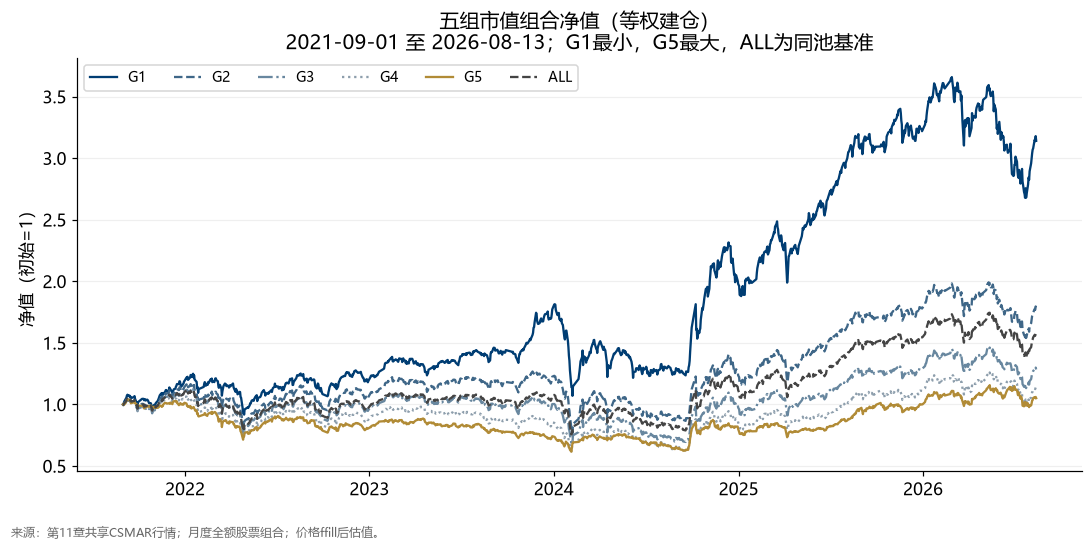

In [11]:
COLORS = {"G1": "#003D73", "G2": "#3F6788", "G3": "#68879F", "G4": "#8D9EAC", "G5": "#B18B36", "ALL": "#444444"}
STYLES = {"G1": "-", "G2": "--", "G3": "-.", "G4": ":", "G5": "-", "ALL": "--"}
PERIOD = f"{ew['gross'].index[0]:%Y-%m-%d} 至 {ew['gross'].index[-1]:%Y-%m-%d}"

def save_figure(fig, name):
    fig.text(0.01, 0.01, "来源：第11章共享CSMAR行情；月度全额股票组合；价格ffill后估值。", fontsize=8, color="#666666")
    fig.tight_layout(rect=(0, 0.045, 1, 1))
    fig.savefig(FIGURES / f"{name}.png", dpi=180)
    fig.savefig(FIGURES / f"{name}.pdf")
    plt.show()

def wealth_with_start(returns):
    wealth = (1 + returns).cumprod()
    # 在第一笔收益之前补上建仓日净值1，方便看清投资起点并正确计算绘图回撤。
    initial = pd.DataFrame(1.0, index=[schedule.execution_date.iloc[0]], columns=returns.columns)
    return pd.concat([initial, wealth])

fig, ax = plt.subplots(figsize=(10, 5))
wealth = wealth_with_start(ew["gross"])
for name in wealth.columns:
    ax.plot(wealth.index, wealth[name], label=name, color=COLORS[name], linestyle=STYLES[name], linewidth=1.5)
ax.set(title=f"五组市值组合净值（等权建仓）\n{PERIOD}；G1最小，G5最大，ALL为同池基准", ylabel="净值（初始=1）")
ax.legend(ncol=6, fontsize=9)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "group_nav")

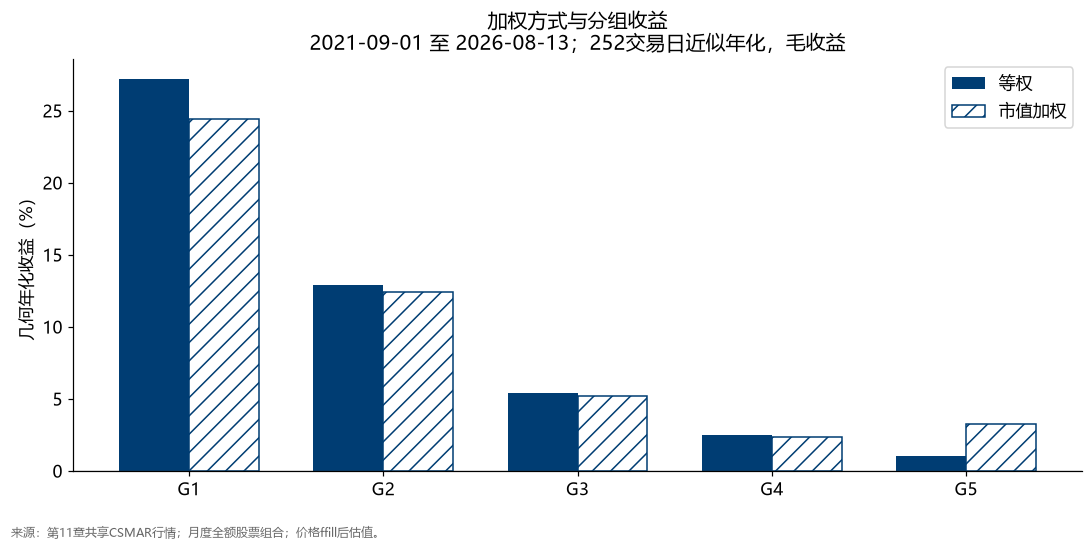

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5)
ew_ann = performance(ew["gross"]).loc[GROUPS, "几何年化收益"] * 100
vw_ann = performance(vw["gross"]).loc[GROUPS, "几何年化收益"] * 100
ax.bar(x - 0.18, ew_ann, width=0.36, color="#003D73", label="等权")
ax.bar(x + 0.18, vw_ann, width=0.36, facecolor="white", edgecolor="#003D73", hatch="//", label="市值加权")
ax.set(xticks=x, xticklabels=GROUPS, ylabel="几何年化收益（%）", title=f"加权方式与分组收益\n{PERIOD}；252交易日近似年化，毛收益")
ax.axhline(0, color="#555555", linewidth=0.8)
ax.legend()
save_figure(fig, "weighting_comparison")

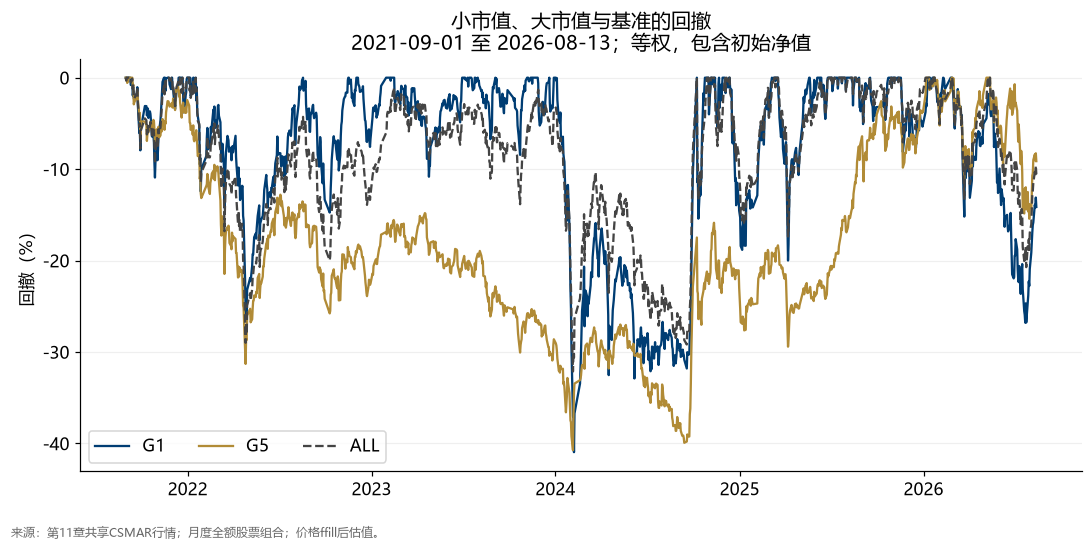

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for name in ["G1", "G5", "ALL"]:
    drawdown = wealth[name] / wealth[name].cummax() - 1
    ax.plot(drawdown.index, drawdown * 100, color=COLORS[name], linestyle=STYLES[name], label=name)
ax.set(title=f"小市值、大市值与基准的回撤\n{PERIOD}；等权，包含初始净值", ylabel="回撤（%）")
ax.legend(ncol=3)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "drawdown")

### 6.2 小减大：先作为研究差值

每月G1持有收益减G5持有收益，用于检查大小市值的相对表现。它没有定义多空资金、保证金、融券和再平衡方式，因此本章不将其连乘成“可投资多空净值”。它也不是标准FF SMB。

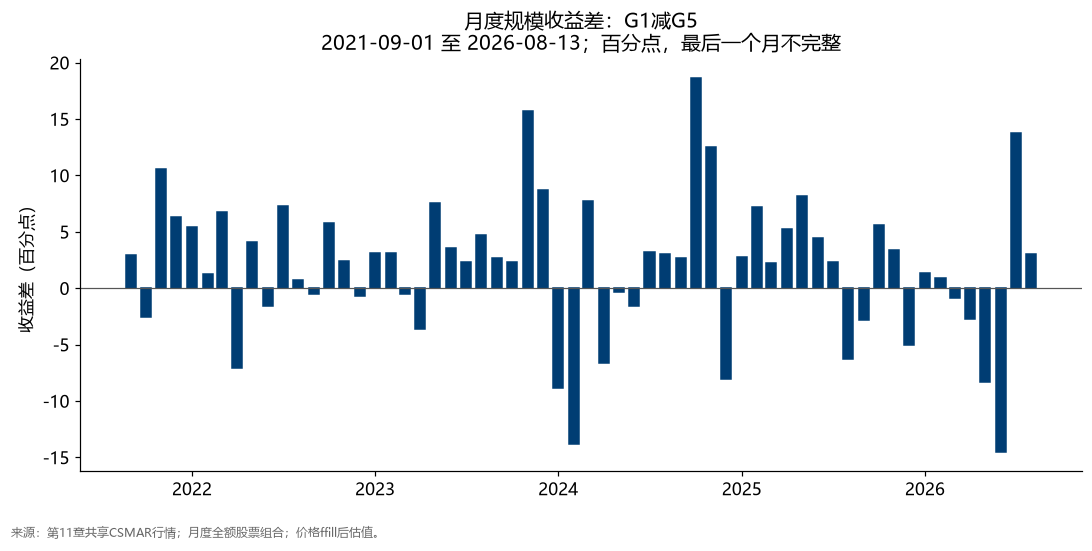

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
spread = monthly["small_minus_big"] * 100
dates = monthly.index.to_timestamp()
ax.bar(dates, spread, width=20, color="#003D73", edgecolor="#003D73")
ax.axhline(0, color="#555555", linewidth=0.8)
ax.set(title=f"月度规模收益差：G1减G5\n{PERIOD}；百分点，最后一个月不完整", ylabel="收益差（百分点）")
save_figure(fig, "monthly_spread")

## 7. 结果是否依赖微盘股票？

在每个信号日先删除市值最小的10%，再重新分成五组。因此这里的G1与基础G1是不同的股票集合。
规则事先固定，不根据哪条净值最好再挑选参数。

,累计收益,几何年化收益,年化波动率,最大回撤
基础G1毛收益,2.1416,0.2723,0.2948,-0.4096
剔除最小10%后G1,1.2932,0.1907,0.2851,-0.4153
同池等权基准,0.5603,0.0981,0.2463,-0.3213


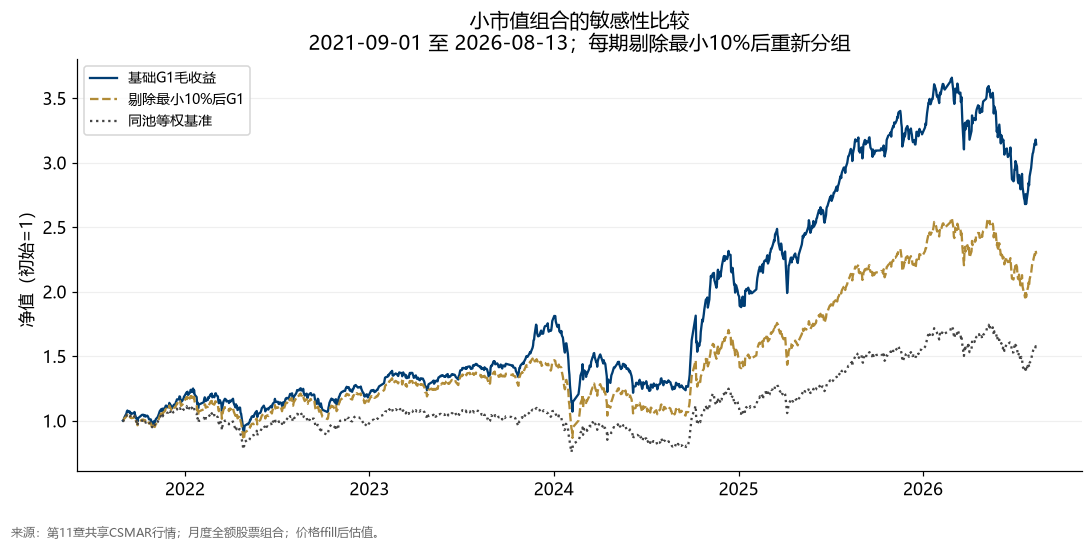

In [15]:
# 把同日期下的不同实验放在一起比较；剔除微盘后的G1与基础G1成员并不相同。
comparison = pd.DataFrame({"基础G1毛收益": ew["gross"].G1,
                           "剔除最小10%后G1": trimmed["gross"].G1,
                           "同池等权基准": ew["gross"].ALL})
sensitivity = performance(comparison)
display(sensitivity.round(4))
fig, ax = plt.subplots(figsize=(10, 5))
for (name, series), color, style in zip(wealth_with_start(comparison).items(),
        ["#003D73", "#B18B36", "#444444"], ["-", "--", ":"]):
    ax.plot(series.index, series, label=name, color=color, linestyle=style)
ax.set(title=f"小市值组合的敏感性比较\n{PERIOD}；每期剔除最小10%后重新分组", ylabel="净值（初始=1）")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "sensitivity")

## 8. 核验排序、权重和收益

独立核算首期G1：逐只股票计算期末价格与建仓价格之比，按初始权重求和，再与组合日收益连乘比较。检查分组数量、权重合计和收益日期，使计算与教学规则一致。

In [16]:
selected = w0.index[w0.G1.gt(0)]
# 逐股计算持有期价值倍数并按初始权重加总，再减1转成持有收益。
manual_first_month = sum(float(w0.loc[s, "G1"] * prices.loc[first.holding_end, s] / prices.loc[first.execution_date, s]) for s in selected) - 1
# 另一条路径：把首期组合日收益连乘，两者应只相差浮点误差。
chained_first_month = first_returns.G1.add(1).prod() - 1
assert np.isclose(manual_first_month, chained_first_month, atol=1e-12)
assert np.allclose(w0.sum(), 1)
assert example.groupby("group").size().max() - example.groupby("group").size().min() <= 1
assert (monthly.index[monthly.complete_month].max() < calendar[-1].to_period("M"))
print("首期逐股加权与日收益连乘误差：", abs(manual_first_month - chained_first_month))

首期逐股加权与日收益连乘误差： 1.021405182655144e-14


### 8.1 解释结果

结果描述这段历史、样本口径和全额股票组合假设下的组间差异。全历史用于教学探索，不是独立样本外检验，也不能据此证明因果关系或alpha。
`ffill()`后的价格作为统一估值，调仓日假定能完成全部买卖。本包没有完整证券生命周期和代码变更映射，结果不等于真实可实现交易业绩。

## 9. 导出主分析结果

输出来源覆盖、调仓日期、组合收益、绩效和微盘敏感性，不复制个股行情。图表和课件数字随Notebook执行更新。

In [17]:
composition = ew["composition"]
tables = {"source_year_profile": profile, "sample_flow": sample_flow, "schedule": schedule,
          "first_sort": example_summary, "performance": summary, "annual_returns": annual,
          "monthly_returns": monthly, "daily_returns_ew": ew["gross"], "daily_returns_vw": vw["gross"],
          "sensitivity": sensitivity, "composition": composition}
for name, table in tables.items():
    table.to_csv(TABLES / f"{name}.csv", encoding="utf-8-sig")

facts = {"source": str(SOURCE.relative_to(ROOT)), "source_rows": source_rows,
    "source_bytes": SOURCE.stat().st_size, "source_mtime": SOURCE.stat().st_mtime,
    "source_start": str(source_start.date()), "source_end": str(source_end.date()),
    "a_share_rows": len(data), "signal_first": str(schedule.signal_date.iloc[0].date()),
    "execution_first": str(schedule.execution_date.iloc[0].date()),
    "return_start": str(ew["gross"].index[0].date()), "return_end": str(ew["gross"].index[-1].date()),
    "return_days": len(ew["gross"]), "rebalances": len(schedule),
    "complete_months": int(monthly.complete_month.sum()), "size_field": SIZE,
    "first_month_check_error": float(abs(manual_first_month - chained_first_month)),
    "small_annualized": float(summary.loc[("等权", "G1"), "几何年化收益"]),
    "big_annualized": float(summary.loc[("等权", "G5"), "几何年化收益"]),
    "small_max_drawdown": float(summary.loc[("等权", "G1"), "最大回撤"]),
    "trimmed_annualized": float(sensitivity.loc["剔除最小10%后G1", "几何年化收益"]),
    "small_monthly_win_rate": float(monthly.loc[monthly.complete_month, "small_minus_big"].gt(0).mean())}
(CHAPTER / "outputs/analysis_summary.json").write_text(json.dumps(facts, ensure_ascii=False, indent=2), encoding="utf-8")
macros = {"DataStart": facts["source_start"], "DataEnd": facts["source_end"],
          "ReturnStart": facts["return_start"], "ReturnEnd": facts["return_end"],
          "ReturnDays": str(facts["return_days"]), "Rebalances": str(facts["rebalances"]),
          "SmallAnn": f"{facts['small_annualized'] * 100:.2f}", "BigAnn": f"{facts['big_annualized'] * 100:.2f}",
          "SmallDD": f"{facts['small_max_drawdown'] * 100:.2f}",
          "TrimAnn": f"{facts['trimmed_annualized'] * 100:.2f}"}
(CHAPTER / "latex/analysis_numbers.tex").write_text("\n".join("\\newcommand{\\" + key + "}{" + value + "}" for key, value in macros.items()) + "\n", encoding="utf-8")
(CHAPTER / "latex/annual_table.tex").write_text((annual[["G1", "G5", "ALL"]] * 100).rename_axis("年份").to_latex(float_format="%.2f"), encoding="utf-8")
print(json.dumps(facts, ensure_ascii=False, indent=2))

{
  "source": "Chapter11 - 股票日频收益率分析\\data\\stock_daily.parquet",
  "source_rows": 6888585,
  "source_bytes": 565150850,
  "source_mtime": 1789023823.9400363,
  "source_start": "2021-08-16",
  "source_end": "2026-08-13",
  "a_share_rows": 6778694,
  "signal_first": "2021-08-30",
  "execution_first": "2021-08-31",
  "return_start": "2021-09-01",
  "return_end": "2026-08-13",
  "return_days": 1198,
  "rebalances": 60,
  "complete_months": 59,
  "size_field": "Dsmvtl2",
  "first_month_check_error": 1.021405182655144e-14,
  "small_annualized": 0.27226134758131804,
  "big_annualized": 0.010479358191714194,
  "small_max_drawdown": -0.40957536761122915,
  "trimmed_annualized": 0.19074331493386842,
  "small_monthly_win_rate": 0.6610169491525424
}


## 10. 课堂练习与下一章

1. 先预测等权与市值加权的差异，再运行并解释结果。
2. 观察不同年份，G1是否始终领先？累计收益是否掩盖了中途回撤？
3. 将 `SIZE` 改为 `Dsmvosd` 并重新执行，解释流通规模与总股本规模的差异。
4. 思考把分组从五组改成十组后，需要同步调整哪些图表与标签。
5. 解释为什么信号日先于建仓日，而建仓日收益不归新组合。

下一章复用排序、权重与收益计算，将市值信号换成动量、反转或低波动。

参考：[Kenneth French因子说明](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_factors.html)。本章小减大是规模收益差，不是标准FF SMB。

## 11. 选学：换手与成本

主分析已完成。本节单独计算等权组合的调仓金额，再观察每边10bp成本情景。
已有持仓的换手为 $\frac12\sum_i|w_i^{new}-w_i^{old}|$，旧权重应使用自然漂移后的期末权重。
首次全额建仓的换手记为1，股票买入金额为1；以后股票买卖总额等于两倍换手。

成本按股票买卖总额计，在新一期首个收益日用 $(1+r)(1-\mathrm{cost})-1$ 扣除；使用毛组合权重估算调仓，是比例扣费教学情景。

In [18]:
COST_PER_SIDE = 0.001  # 每买入或卖出1元，假设支付0.001元。
previous_weights = pd.DataFrame(0.0, index=prices.columns, columns=GROUPS + ["ALL"])
cost_rows = []
net_returns = ew["gross"].copy()
for period, row in enumerate(schedule.itertuples(index=False)):
    weights = target_weights(sort_stocks(row.signal_date), "EW")
    # 新目标减上期末权重；绝对值之和同时包含买入和卖出。
    traded = (weights - previous_weights).abs().sum()
    turnover = traded if period == 0 else traded / 2
    first_day = calendar[calendar > row.execution_date][0]
    net_returns.loc[first_day] = (1 + net_returns.loc[first_day]) * (1 - COST_PER_SIDE * traded) - 1
    for group in weights:
        cost_rows.append(dict(execution_date=row.execution_date, group=group,
                              turnover=turnover[group], traded_notional=traded[group]))
    # 初始权重乘本期末资产倍数，再归一化，得到下次调仓前的股票权重。
    selected = weights.index[weights.sum(axis=1).gt(0)]
    relative_end = prices.loc[row.holding_end, selected] / prices.loc[row.execution_date, selected]
    end_value = weights.loc[selected].mul(relative_end, axis=0)
    previous_weights = weights * 0
    previous_weights.loc[selected] = end_value.div(end_value.sum(), axis=1)
    assert np.allclose(previous_weights.sum(), 1)

cost_table = pd.DataFrame(cost_rows)
cost_comparison = pd.DataFrame({"G1毛收益": ew["gross"].G1, "G1成本后": net_returns.G1})
display(performance(cost_comparison).round(4))
# 成本非负时，扣费后终值不应超过毛收益终值。
assert ((1 + net_returns).prod() <= (1 + ew["gross"]).prod() + 1e-12).all()
cost_table.to_csv(TABLES / "optional_turnover.csv", index=False, encoding="utf-8-sig")
net_returns.to_csv(TABLES / "optional_net_returns.csv", encoding="utf-8-sig")
performance(cost_comparison).to_csv(TABLES / "optional_cost_performance.csv", encoding="utf-8-sig")


,累计收益,几何年化收益,年化波动率,最大回撤
G1毛收益,2.1416,0.2723,0.2948,-0.4096
G1成本后,2.0944,0.2682,0.2947,-0.4097


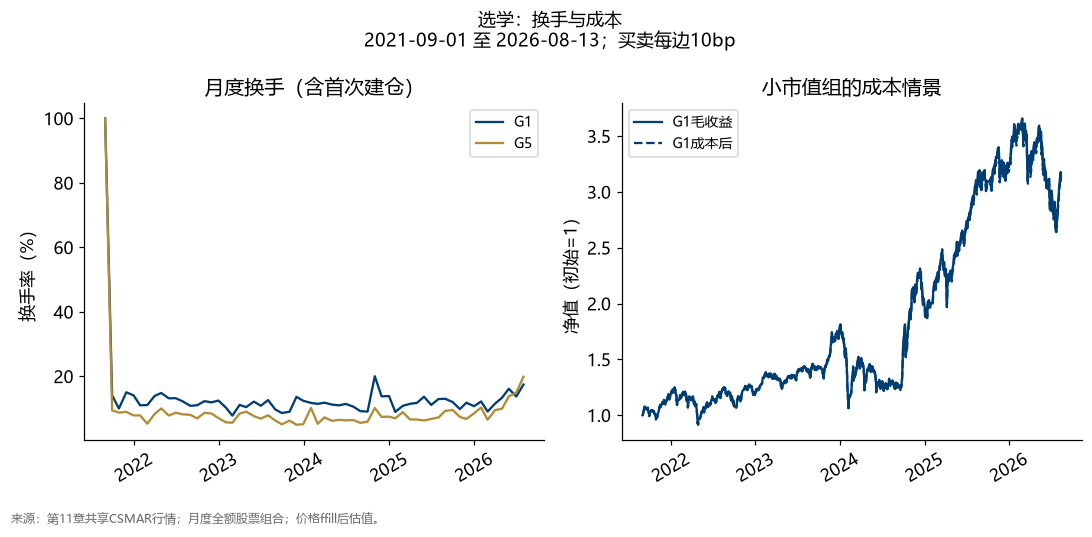

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
for group in ["G1", "G5"]:
    part = cost_table.loc[cost_table.group.eq(group)]
    axes[0].plot(part.execution_date, part.turnover * 100, label=group, color=COLORS[group], linestyle=STYLES[group])
for (name, series), style in zip(wealth_with_start(cost_comparison).items(), ["-", "--"]):
    axes[1].plot(series.index, series, label=name, color="#003D73", linestyle=style)
axes[0].set(title="月度换手（含首次建仓）", ylabel="换手率（%）")
axes[1].set(title="小市值组的成本情景", ylabel="净值（初始=1）")
for ax in axes:
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle(f"选学：换手与成本\n{PERIOD}；买卖每边10bp", fontsize=12)
save_figure(fig, "optional_turnover_cost")
